In [16]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, MultiHeadAttention, Conv1D, LSTM, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tqdm import tqdm

# 1️⃣ Chargement des séries temporelles sans perte d'information
def load_time_series(directory, max_files=100, sequence_length=30):
    ids = os.listdir(directory)[:max_files]  # Limite à 100 fichiers
    sequences, all_ids = [], []
    
    for id_dir in tqdm(ids):
        file_path = os.path.join(directory, id_dir, 'part-0.parquet')
        if os.path.exists(file_path):
            df = pd.read_parquet(file_path)
            df['id'] = id_dir  # Associer l'ID du participant
            
            if 'step' in df.columns:
                df = df.drop('step', axis=1)  # Supprimer la colonne inutile
                
            df = df.select_dtypes(include=[np.number])  # Garder uniquement les colonnes numériques
            
            if len(df) >= sequence_length:
                df = df.iloc[:sequence_length]  # Prendre une fenêtre de taille fixe
                sequences.append(df.values)
                all_ids.append(id_dir)
    
    return np.array(sequences), all_ids

# Ajout du Positional Encoding
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, sequence_length, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_length = sequence_length
        self.d_model = d_model
        
    def build(self, input_shape):
        positions = np.arange(self.sequence_length)[:, np.newaxis]
        div_terms = np.exp(np.arange(0, self.d_model, 2) * -(np.log(10000.0) / self.d_model))
        pos_enc = np.zeros((self.sequence_length, self.d_model))
        pos_enc[:, 0::2] = np.sin(positions * div_terms)
        pos_enc[:, 1::2] = np.cos(positions * div_terms)
        self.positional_encoding = tf.cast(pos_enc[np.newaxis, ...], dtype=tf.float32)
    
    def call(self, inputs):
        return inputs + self.positional_encoding[:, :tf.shape(inputs)[1], :]

# Définition du modèle Transformer
def build_transformer_model(sequence_length, feature_dim, tabular_dim, num_classes, d_model=64, num_heads=4, ff_dim=128, num_layers=3, dropout=0.1):
    series_input = Input(shape=(sequence_length, feature_dim))
    tabular_input = Input(shape=(tabular_dim,))
    
    x = Dense(d_model)(series_input)
    x = PositionalEncoding(sequence_length, d_model)(x)
    
    for _ in range(num_layers):
        Q = Dense(d_model)(x)
        K = Dense(d_model)(x)
        V = Dense(d_model)(x)
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(Q, K, V)
        attention_output = Dropout(dropout)(attention_output)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)
        ffn_output = Dense(ff_dim, activation='relu')(x)
        ffn_output = Dense(d_model)(ffn_output)
        ffn_output = Dropout(dropout)(ffn_output)
        x = LayerNormalization(epsilon=1e-6)(x + ffn_output)
    
    x = Flatten()(x)
    tabular_x = Dense(32, activation='relu')(tabular_input)
    tabular_x = Dense(16, activation='relu')(tabular_x)
    
    concat = keras.layers.concatenate([x, tabular_x])
    outputs = Dense(num_classes, activation="softmax")(concat)
    
    model = Model([series_input, tabular_input], outputs)
    model.compile(optimizer=AdamW(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Charger les séries temporelles et les données tabulaires
sequence_length = 30  # Taille des séquences
series_train, series_ids = load_time_series("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/series_train.parquet", max_files=100, sequence_length=sequence_length)
tabular_train_df = pd.read_csv("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/train.csv")

# Vérifications initiales
print("Avant dropna, shape :", tabular_train_df.shape)
tabular_train_df = tabular_train_df.dropna(subset=['sii'])
print("Après dropna, shape :", tabular_train_df.shape)

# Nettoyage et conversion des IDs
tabular_train_df['id'] = tabular_train_df['id'].astype(str)
series_ids = [id_.replace("id=", "") for id_ in series_ids]
series_ids = list(map(str, series_ids))

# Assurer la correspondance des IDs
tabular_train_df = tabular_train_df[tabular_train_df['id'].isin(series_ids)].copy()
series_train = np.array([series_train[series_ids.index(id_)] for id_ in tabular_train_df['id']])

print("Nouvelle shape de series_train :", series_train.shape)
print("Nouvelle shape de tabular_train_df :", tabular_train_df.shape)

# Séparation des labels
labels = tabular_train_df['sii'].astype(int).values
num_classes = len(np.unique(labels))
print("Nombre de classes uniques détectées :", num_classes)

# Encodage des labels
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
labels = encoder.fit_transform(labels.reshape(-1, 1))
print("Shape des labels après encodage :", labels.shape)

# Normalisation des features
train_df = tabular_train_df.drop(columns=['sii', 'id'], errors='ignore')
numeric_features = train_df.select_dtypes(include=[np.number])
tabular_features = StandardScaler().fit_transform(numeric_features)

# Séparation en train/val
x_train, x_val, y_train, y_val, tab_train, tab_val = train_test_split(series_train, labels, tabular_features, test_size=0.2, random_state=42)

# Entraînement du modèle
model = build_transformer_model(sequence_length=sequence_length, feature_dim=series_train.shape[-1], tabular_dim=tabular_features.shape[1], num_classes=num_classes)
history = model.fit([x_train, tab_train], y_train, validation_data=([x_val, tab_val], y_val), epochs=30, batch_size=32)

print("\n✅ Modèle entraîné avec succès !")


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:06<00:00, 15.88it/s]


Avant dropna, shape : (3960, 82)
Après dropna, shape : (2736, 82)
Nouvelle shape de series_train : (100, 30, 12)
Nouvelle shape de tabular_train_df : (100, 82)
Nombre de classes uniques détectées : 3
Shape des labels après encodage : (100, 3)
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 458ms/step - accuracy: 0.5938 - loss: 1.3358 - val_accuracy: 0.4500 - val_loss: 1.0536
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3883 - loss: 1.1159 - val_accuracy: 0.3500 - val_loss: 1.2081
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2930 - loss: 1.1994 - val_accuracy: 0.4500 - val_loss: 1.1438
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5367 - loss: 0.9075 - val_accuracy: 0.4500 - val_loss: 1.3075
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5648 - loss: 1.0878 - val_accuracy: 0.4500 - val_loss: 1.3059
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5570 - loss: 1.0961 - val_accuracy: 0.4500 - val_loss: 1.1651
Epoc

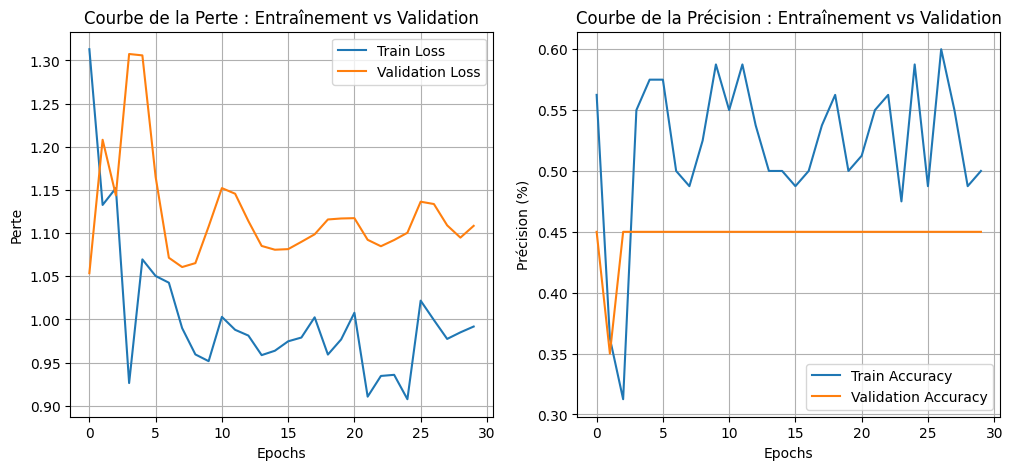

In [17]:
import matplotlib.pyplot as plt
# Fonction pour afficher les courbes d'entraînement
def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Courbe de la perte
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Courbe de la Perte : Entraînement vs Validation')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Perte')
    axes[0].legend()
    axes[0].grid()
    
    # Courbe de la précision
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Courbe de la Précision : Entraînement vs Validation')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Précision (%)')
    axes[1].legend()
    axes[1].grid()
    
    plt.show()

plot_training_curves(history)